EXPRT: 02
COMPARATIVE STUDY OF ACTIVATION FUNCTIONS AND OPTIMIZATION ALGORITHMS IN DEEP LEARNING

PART A: VISUALIZATION OF ACTIVATION FUNCTIONS

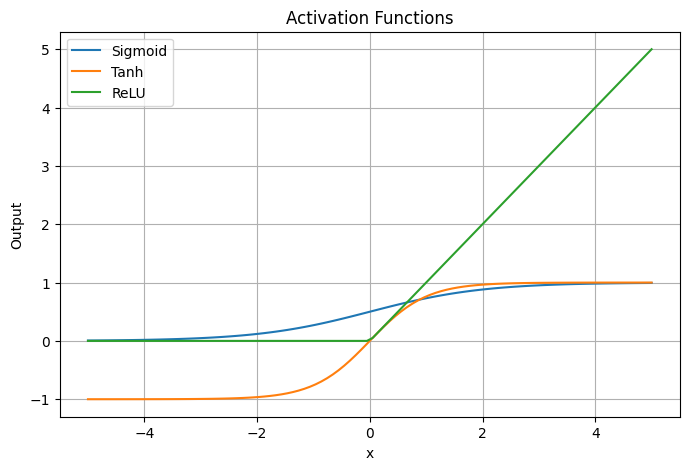

In [15]:
# Roll No: 24BAD009

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu, label="ReLU")

plt.title("Activation Functions")
plt.xlabel("x")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()

PART B: PERFORMANCE COMPARISON OF ACTIVATION FUNCTIONS

In [16]:
# Roll No: 24BAD009

import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [17]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()


In [18]:
# Normalize data
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0

In [19]:
# Function to create model
def create_model(act):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation=act, input_shape=(784,)),
        tf.keras.layers.Dense(64, activation=act),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [6]:
# Compare activation functions
for act in ["sigmoid", "tanh", "relu"]:
    print("\nActivation:", act)

    model = create_model(act)

    model.fit(
        X_train,
        y_train,
        epochs=5,
        validation_split=0.2,
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test)

    print("Test Accuracy:", acc)


Activation: sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.8691 - loss: 0.5308 - val_accuracy: 0.9341 - val_loss: 0.2300
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9407 - loss: 0.2014 - val_accuracy: 0.9525 - val_loss: 0.1707
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9579 - loss: 0.1428 - val_accuracy: 0.9609 - val_loss: 0.1369
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9675 - loss: 0.1087 - val_accuracy: 0.9661 - val_loss: 0.1181
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9758 - loss: 0.0850 - val_accuracy: 0.9694 - val_loss: 0.1031
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.0953
Test Accuracy: 0.9688000082969666

Activation: tanh
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9152 - loss: 0.2912 - val_accuracy: 0.9495 - val_loss: 0.1741
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9598 - loss: 0.1338 - val_accur

PART C: COMPARISON OF OPTIMIZATION ALGORITHMS

In [7]:
# Roll No: 24BAD009

import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [8]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [9]:
# Normalize data
X_train = X_train.reshape(-1, 784) / 255.0
X_test = X_test.reshape(-1, 784) / 255.0


In [10]:
# Optimizers
optimizers = {
    "SGD": tf.keras.optimizers.SGD(),
    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam()
}

In [11]:
# Store histories
histories = {}


In [12]:
# Train models
for name, optimizer in optimizers.items():

    print("\nTraining with", name)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )

    histories[name] = history

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n{name}")
    print("Test Loss :", round(loss, 4))
    print("Test Accuracy :", round(accuracy, 4))


Training with SGD
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8127 - loss: 0.7139 - val_accuracy: 0.9047 - val_loss: 0.3427
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9083 - loss: 0.3210 - val_accuracy: 0.9215 - val_loss: 0.2806
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9239 - loss: 0.2659 - val_accuracy: 0.9335 - val_loss: 0.2341
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9342 - loss: 0.2312 - val_accuracy: 0.9421 - val_loss: 0.2104
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9416 - loss: 0.2052 - val_accuracy: 0.9461 - val_loss: 0.1957

SGD
Test Loss : 0.1938
Test Accuracy : 0.9429

Training with Momentum
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9033 - loss: 0.3179 - val_accuracy: 0.9560 - val_loss: 0.1519
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9604 - loss: 0.1316 - val_accuracy: 0.9611 - val_loss: 0.1287
Epoch 

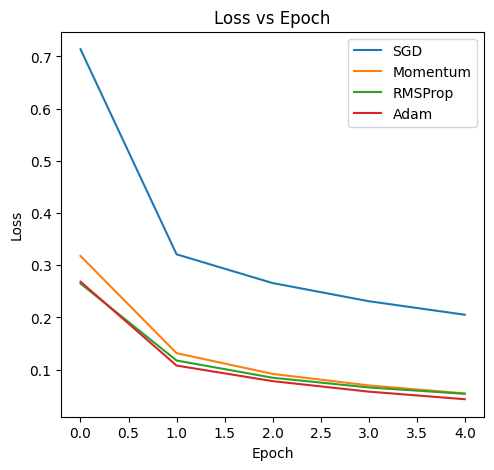

In [13]:
# ---------------- Loss Graph ----------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

for name in histories:
    plt.plot(histories[name].history["loss"], label=name)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

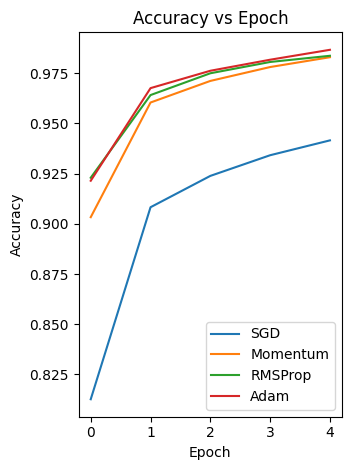

In [14]:
# ---------------- Accuracy Graph ----------------
plt.subplot(1, 2, 2)

for name in histories:
    plt.plot(histories[name].history["accuracy"], label=name)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()